In [41]:
# ==================================================
# Configuració del projecte
# ==================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

MASTER_CSV = "../data/processed/indicators_dataset.csv"   # fitxer amb territori, any, indicador_gentrificacio
GEO_JSON   = "../data/raw/0301100100_UNITATS_ADM_POLIGONS.json"   # geometries
OUT_FIG    = Path("../reports/figures"); OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB    = Path("../reports/tables"); OUT_TAB.mkdir(parents=True, exist_ok=True)
OUT_PROC   = Path("../data/processed"); OUT_PROC.mkdir(parents=True, exist_ok=True)


In [43]:
# ==================================================
# Imports
# ==================================================

import pandas as pd
import geopandas as gpd
from pathlib import Path
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


In [45]:
# -----------------------------
# Carregar dades
# -----------------------------
df = gpd.read_file("data/df_geo_final.geojson")

In [46]:
# -----------------------------
# Variables del model
# -----------------------------
features = [
    "indicador_socio",
    "indicador_housing",
    "indicador_demo",
    "indicador_turisme"
]

# Eliminar NaNs
df_model = df.dropna(subset=features + ["cluster"]).copy()

# Variables predictives
X = df_model[features]

# Variable objectiu
y = df_model["cluster"]

In [49]:
# -----------------------------
# Normalització
# -----------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [51]:
# -----------------------------
# Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


REGRESSIÓ LOGÍSTICA

Accuracy: 0.4681

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.38      0.43        77
           1       0.49      0.83      0.62       157
           2       0.20      0.11      0.14        54
           3       0.50      0.11      0.19        88

    accuracy                           0.47       376
   macro avg       0.42      0.36      0.34       376
weighted avg       0.45      0.47      0.41       376



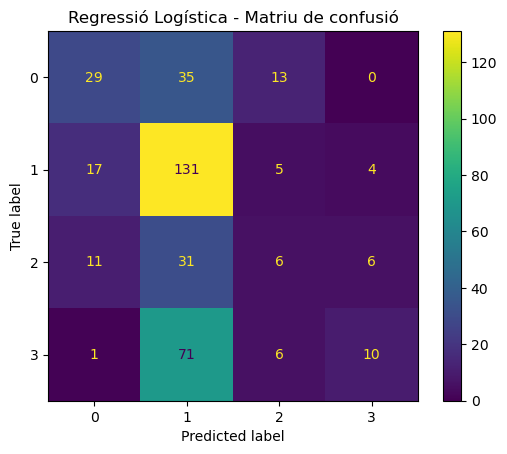

In [53]:
# ============================================================
# REGRESSIÓ LOGÍSTICA
# ============================================================

print("\n==============================")
print("REGRESSIÓ LOGÍSTICA")
print("==============================")

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)

print(f"\nAccuracy: {acc_log:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log
)

disp.plot()
plt.title("Regressió Logística - Matriu de confusió")
plt.show()


RANDOM FOREST

Accuracy: 0.6170

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.70      0.67        77
           1       0.63      0.82      0.71       157
           2       0.47      0.46      0.47        54
           3       0.69      0.28      0.40        88

    accuracy                           0.62       376
   macro avg       0.61      0.57      0.56       376
weighted avg       0.63      0.62      0.60       376



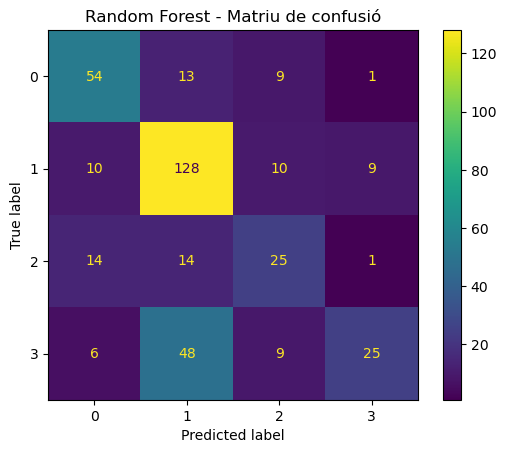

In [55]:
# ============================================================
# RANDOM FOREST
# ============================================================

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nAccuracy: {acc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()
plt.title("Random Forest - Matriu de confusió")
plt.savefig(OUT_FIG/"Matriu_confusio.png", dpi=300)
plt.show()


Importància de variables:
            Variable  Importancia
2     indicador_demo     0.392522
1  indicador_housing     0.230882
0    indicador_socio     0.193420
3  indicador_turisme     0.183176


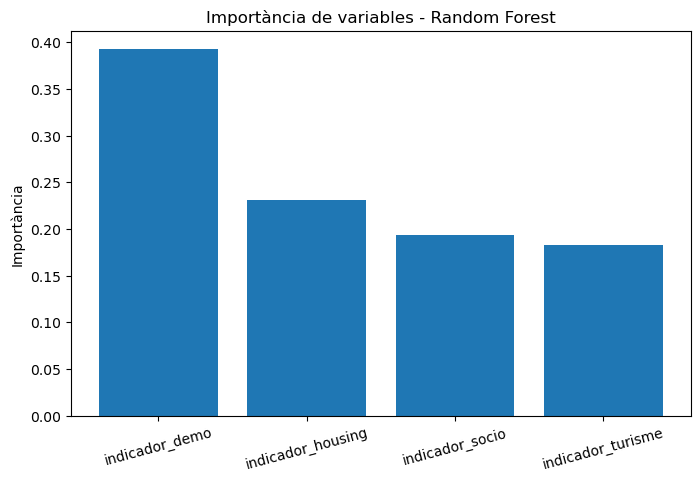

In [57]:
# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.DataFrame({
    "Variable": features,
    "Importancia": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importancia",
    ascending=False
)

print("\nImportància de variables:")
print(importance)

plt.figure(figsize=(8,5))

plt.bar(
    importance["Variable"],
    importance["Importancia"]
)

plt.title("Importància de variables - Random Forest")
plt.ylabel("Importància")

plt.xticks(rotation=15)
plt.savefig(OUT_FIG/"Importancia_variable_rf.png", dpi=300)


plt.show()


GRADIENT BOOSTING

Accuracy: 0.5957

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68        77
           1       0.61      0.78      0.69       157
           2       0.45      0.41      0.43        54
           3       0.57      0.30      0.39        88

    accuracy                           0.60       376
   macro avg       0.57      0.55      0.54       376
weighted avg       0.59      0.60      0.58       376



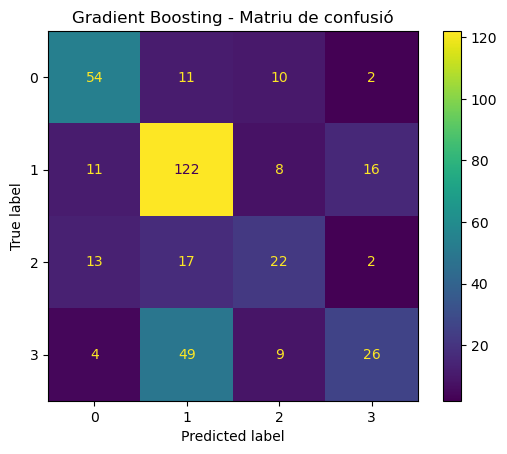

In [59]:
# ============================================================
# GRADIENT BOOSTING
# ============================================================

print("\n==============================")
print("GRADIENT BOOSTING")
print("==============================")

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)

print(f"\nAccuracy: {acc_gb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

cm_gb = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb
)

disp.plot()
plt.title("Gradient Boosting - Matriu de confusió")
plt.show()


RESULTATS FINALS
                 Model  Accuracy
0  Logistic Regression  0.468085
1        Random Forest  0.617021
2    Gradient Boosting  0.595745


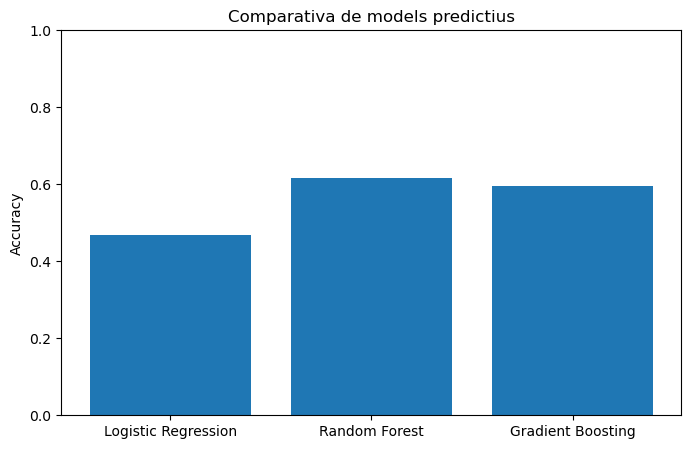

[0.46010638 0.37234043 0.5212766  0.35904255 0.29866667]
0.40228652482269506


In [61]:
# ============================================================
# COMPARATIVA DE MODELS
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        acc_log,
        acc_rf,
        acc_gb
    ]
})

print("\n==============================")
print("RESULTATS FINALS")
print("==============================")

print(results)

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Comparativa de models predictius")

plt.show()


scores = cross_val_score(
    rf_model,
    X_scaled,
    y,
    cv=5
)

print(scores)
print(scores.mean())

In [62]:
# ============================================================
# EXPORTAR RESULTATS
# ============================================================

results.to_csv(
    "resultats_models.csv",
    index=False
)

importance.to_csv(
    "importancia_variables_rf.csv",
    index=False
)

print("\nFitxers exportats correctament.")


Fitxers exportats correctament.


In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_gb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_log, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_gb, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_gb, average="weighted")
    ]
})

print(results.round(3))

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression     0.468      0.452   0.468     0.409
1        Random Forest     0.617      0.625   0.617     0.596
2    Gradient Boosting     0.596      0.588   0.596     0.577
